## Cell 1 — Imports and Configuration

In [1]:
import time
import warnings
import subprocess, sys

# Install extra libraries if needed
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "xgboost", "lightgbm"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# preprocessing
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

# Sklearn — models
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier

# metrics
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report, confusion_matrix,
)

# Boosting
import xgboost  as xgb
import lightgbm as lgb


# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Paths 
FEATURE_PATH = Path("/kaggle/input/datasets/tahu663/putemg-window-feature-dataset-parquet/putemg_window_feature_dataset.parquet")
OUTPUT_FOLDER = Path("/kaggle/working/task2_results")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Gesture label map (same as Task 1)
GESTURE_NAMES = {
    0: "Idle",        1: "Fist",
    2: "Flexion",     3: "Extension",
    6: "Pinch-Index", 7: "Pinch-Middle",
    8: "Pinch-Ring",  9: "Pinch-Small",
}

print("Setup complete.")

Setup complete.


## Cell 2 — Load Feature Dataset

In [2]:
feature_df = pd.read_parquet(FEATURE_PATH)

# Identify the 192 EMG feature columns
import re
# IEMG = MAV × 1024 for every fixed 1024-sample window — mathematically redundant
# Established in Task 1 EDA. Removing 24 IEMG columns → 168 features.
FEAT_PAT  = re.compile(r"EMG_\d+_(MAV|RMS|STD|VAR|WL|ZC|SSC)", re.I)
feat_cols = [c for c in feature_df.columns if FEAT_PAT.fullmatch(c)]

assert len(feat_cols) == 168, f"Expected 168 features (192 minus 24 IEMG), got {len(feat_cols)}"

print(f"Dataset shape    : {feature_df.shape}")
print(f"Feature columns  : {len(feat_cols)}")
print(f"Subjects         : {sorted(feature_df['subject_id'].unique())}")
print(f"Classes          : {sorted(feature_df['label'].unique())}")
print(f"Windows per class:")
display(feature_df["label"].map(GESTURE_NAMES).value_counts().to_frame("count"))

Dataset shape    : (619479, 196)
Feature columns  : 168
Subjects         : [np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12), np.int16(13), np.int16(14), np.int16(15), np.int16(16), np.int16(17), np.int16(18), np.int16(19), np.int16(20), np.int16(22), np.int16(23), np.int16(24), np.int16(25), np.int16(26), np.int16(27), np.int16(29), np.int16(30), np.int16(31), np.int16(33), np.int16(34), np.int16(35), np.int16(36), np.int16(38), np.int16(39), np.int16(42), np.int16(43), np.int16(45), np.int16(46), np.int16(47), np.int16(48), np.int16(49), np.int16(50), np.int16(51), np.int16(53), np.int16(54)]
Classes          : [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(6), np.int8(7), np.int8(8), np.int8(9)]
Windows per class:


,count
label,
Idle,380337
Fist,35638
Flexion,35356
Extension,34228
Pinch-Small,33799
Pinch-Index,33649
Pinch-Middle,33552
Pinch-Ring,32920


## Cell 3 — Subject-Independent Train / Test Split



In [3]:
all_subjects = np.array(sorted(feature_df["subject_id"].unique()))
n_subjects   = len(all_subjects)

# Fixed subject-wise split: 31 train / 6 validation / 7 test
# Shuffled with a fixed seed so the split is reproducible
rng = np.random.default_rng(RANDOM_STATE)
subjects = rng.permutation(all_subjects)

test_subjects  = subjects[:7]
val_subjects   = subjects[7:13]
train_subjects = subjects[13:]

train_df = feature_df[feature_df["subject_id"].isin(train_subjects)].copy()
val_df   = feature_df[feature_df["subject_id"].isin(val_subjects)].copy()
test_df  = feature_df[feature_df["subject_id"].isin(test_subjects)].copy()

print(f"Total subjects   : {n_subjects}")
print(f"Train subjects   : {len(train_subjects)}  → {sorted(train_subjects.tolist())}")
print(f"Val   subjects   : {len(val_subjects)}   → {sorted(val_subjects.tolist())}")
print(f"Test  subjects   : {len(test_subjects)}   → {sorted(test_subjects.tolist())}")
print(f"\nTrain windows : {len(train_df):,}")
print(f"Val   windows : {len(val_df):,}")
print(f"Test  windows : {len(test_df):,}")

# Sanity check — no subject overlap across any two partitions
assert set(train_subjects).isdisjoint(val_subjects),  "Train/val overlap!"
assert set(train_subjects).isdisjoint(test_subjects), "Train/test overlap!"
assert set(val_subjects).isdisjoint(test_subjects),   "Val/test overlap!"
print("Subject-independence check passed.")


Total subjects   : 44
Train subjects   : 31  → [3, 4, 5, 6, 9, 11, 12, 13, 14, 15, 16, 17, 18, 20, 22, 23, 25, 26, 31, 33, 36, 38, 39, 42, 43, 45, 46, 47, 48, 49, 53]
Val   subjects   : 6   → [8, 10, 19, 27, 29, 35]
Test  subjects   : 7   → [7, 24, 30, 34, 50, 51, 54]

Train windows : 435,797
Val   windows : 85,277
Test  windows : 98,405
Subject-independence check passed.


In [4]:
expected_labels = set(GESTURE_NAMES.keys())

for name, df_split in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}.items():
    present = set(df_split["label"].unique())
    assert present == expected_labels, (
        f"{name} missing classes: {expected_labels - present}"
    )

print("All 8 gesture classes are present in every split.")

All 8 gesture classes are present in every split.


## Cell 4 — Preprocessing

All preprocessing is **fitted on the training set only**, then applied to both.
This avoids any leakage of test-set statistics into the model.

In [5]:
X_train_raw = train_df[feat_cols].to_numpy(dtype="float32")
X_val_raw   = val_df[feat_cols].to_numpy(dtype="float32")
X_test_raw  = test_df[feat_cols].to_numpy(dtype="float32")
y_train     = train_df["label"].to_numpy()
y_val       = val_df["label"].to_numpy()
y_test      = test_df["label"].to_numpy()

# Step 1: Remove near-zero-variance features (fit on train only) 
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_raw)
X_train_vt = vt.transform(X_train_raw)
X_val_vt   = vt.transform(X_val_raw)
X_test_vt  = vt.transform(X_test_raw)
print(f"Features after variance filter : {X_train_vt.shape[1]} "
      f"(removed {X_train_raw.shape[1] - X_train_vt.shape[1]})")

#  Step 2: Scale with RobustScaler (fit on train only) 
# RobustScaler uses median and IQR — less sensitive to EMG outliers
scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train_vt).astype("float32")
X_val   = scaler.transform(X_val_vt).astype("float32")
X_test  = scaler.transform(X_test_vt).astype("float32")
print(f"Scaling done.  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

#  Step 3: Encode labels to 0-based integers 
# Original labels are [0,1,2,3,6,7,8,9] — not consecutive
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)
n_classes   = len(le.classes_)
class_names = [GESTURE_NAMES[c] for c in le.classes_]
print(f"Classes ({n_classes}): {dict(zip(le.classes_, class_names))}")

#  Step 4: Class weights (for models that accept class_weight) 
from sklearn.utils.class_weight import compute_class_weight
cw_values = compute_class_weight("balanced", classes=np.unique(y_train_enc),
                                  y=y_train_enc)
class_weight_dict = dict(enumerate(cw_values))
print(f"Class weights: { {class_names[k]: round(v,2) for k,v in class_weight_dict.items()} }")

#  Imbalance handling strategy 
# Global SMOTE removed: it expanded the dataset to 2.4M rows, slowing every
# model and combining with weighted loss to double-correct imbalance.
# Instead we use model-appropriate handling:
#   LR, SVM, DT, RF, LGBM → class_weight="balanced"
#   XGB, GB                → sample_weight computed per-window
#   kNN                    → original distribution (kNN has no weight param)
#   MLP, CNN               → weighted CrossEntropyLoss on original X_train
# SVM/GB subsets are now stratified samples from original X_train (not SMOTE).

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight("balanced", y=y_train_enc)

print("\nPreprocessing complete — no global SMOTE applied.")
print("Each model uses its own imbalance correction (see comments above).")


Features after variance filter : 168 (removed 0)
Scaling done.  Train: (435797, 168)  Val: (85277, 168)  Test: (98405, 168)
Classes (8): {np.int8(0): 'Idle', np.int8(1): 'Fist', np.int8(2): 'Flexion', np.int8(3): 'Extension', np.int8(6): 'Pinch-Index', np.int8(7): 'Pinch-Middle', np.int8(8): 'Pinch-Ring', np.int8(9): 'Pinch-Small'}
Class weights: {'Idle': np.float64(0.2), 'Fist': np.float64(2.16), 'Flexion': np.float64(2.18), 'Extension': np.float64(2.27), 'Pinch-Index': np.float64(2.29), 'Pinch-Middle': np.float64(2.27), 'Pinch-Ring': np.float64(2.33), 'Pinch-Small': np.float64(2.27)}

Preprocessing complete — no global SMOTE applied.
Each model uses its own imbalance correction (see comments above).


## Cell 5 — Metric Helper Function

In [6]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
)

results = []   # stores one dict per model

def evaluate(name, model_or_proba, y_true, y_pred, train_time,
             split_label="Validation"):
    """Compute full metric set and store results.
    model_or_proba: fitted sklearn model OR pre-computed probability array.
    Evaluates on the given split (default: Validation).
    """
    acc      = accuracy_score(y_true, y_pred)
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    mac_f1   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    wgt_f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mac_prec = precision_score(y_true, y_pred, average="macro",    zero_division=0)
    mac_rec  = recall_score(y_true, y_pred, average="macro",    zero_division=0)
    wgt_prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    wgt_rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)

    # ROC-AUC and PR-AUC (one-vs-rest, requires probability scores)
    roc_auc, pr_auc = None, None
    if model_or_proba is not None:
        if isinstance(model_or_proba, np.ndarray):
            proba = model_or_proba   # pre-computed array passed directly
        elif hasattr(model_or_proba, "predict_proba"):
            proba = model_or_proba.predict_proba(
                X_val if split_label == "Validation" else X_test)
        elif hasattr(model_or_proba, "decision_function"):
            proba = model_or_proba.decision_function(
                X_val if split_label == "Validation" else X_test)
        else:
            proba = None
        if proba is not None:
            try:
                roc_auc = roc_auc_score(y_true, proba, multi_class="ovr",
                                        average="macro")
                pr_auc  = average_precision_score(
                    np.eye(n_classes)[y_true], proba, average="macro")
            except Exception:
                pass

    print(f"  [{split_label}]")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Balanced Accuracy : {bal_acc:.4f}")
    print(f"  Macro-F1          : {mac_f1:.4f}  ← primary metric")
    print(f"  Macro Precision   : {mac_prec:.4f}")
    print(f"  Macro Recall      : {mac_rec:.4f}")
    print(f"  Weighted-F1       : {wgt_f1:.4f}")
    if roc_auc is not None:
        print(f"  ROC-AUC (macro)   : {roc_auc:.4f}")
        print(f"  PR-AUC  (macro)   : {pr_auc:.4f}")
    print(f"  Train time        : {train_time:.1f}s")

    # Per-class report
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=class_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix — {name} ({split_label})", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    results.append({
        "Model"             : name,
        "Accuracy"          : round(acc,     4),
        "Balanced Accuracy" : round(bal_acc, 4),
        "Macro-F1"          : round(mac_f1,  4),
        "Macro Precision"   : round(mac_prec,4),
        "Macro Recall"      : round(mac_rec, 4),
        "Weighted-F1"       : round(wgt_f1,  4),
        "Weighted Precision": round(wgt_prec,4),
        "Weighted Recall"   : round(wgt_rec, 4),
        "ROC-AUC"           : round(roc_auc, 4) if roc_auc is not None else None,
        "PR-AUC"            : round(pr_auc,  4) if pr_auc  is not None else None,
        "Train time (s)"    : round(train_time, 1),
    })

print("Metric helper ready.")
print("Note: all baselines are evaluated on VALIDATION set.")
print("Test set is reserved for final GNN vs best-baseline comparison.")


Metric helper ready.
Note: all baselines are evaluated on VALIDATION set.
Test set is reserved for final GNN vs best-baseline comparison.


## Model 1 — Logistic Regression

Training Logistic Regression ...
LR iterations used: 100/3000
Logistic Regression converged successfully.
  [Validation]
  Accuracy          : 0.4958
  Balanced Accuracy : 0.3340
  Macro-F1          : 0.2225  ← primary metric
  Macro Precision   : 0.3624
  Macro Recall      : 0.3340
  Weighted-F1       : 0.5115
  ROC-AUC (macro)   : 0.6539
  PR-AUC  (macro)   : 0.2780
  Train time        : 274.8s

              precision    recall  f1-score   support

        Idle       0.91      0.62      0.74     52364
        Fist       0.15      0.36      0.22      4913
     Flexion       0.30      0.68      0.42      4825
   Extension       0.17      0.95      0.29      4706
 Pinch-Index       0.64      0.02      0.03      4723
Pinch-Middle       0.08      0.02      0.03      4577
  Pinch-Ring       0.14      0.00      0.01      4489
 Pinch-Small       0.49      0.03      0.05      4680

    accuracy                           0.50     85277
   macro avg       0.36      0.33      0.22     85277
wei

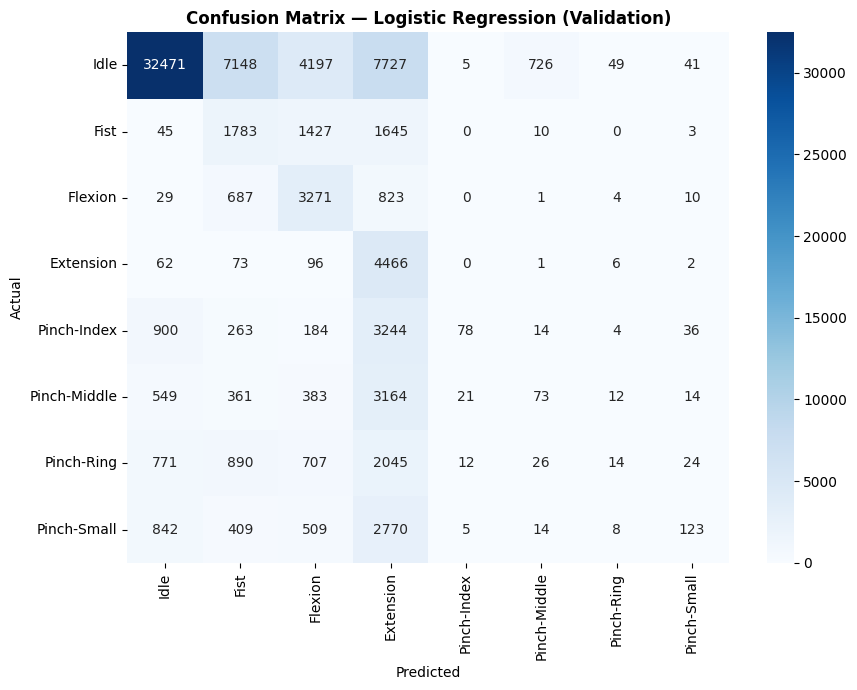

In [7]:
print("Training Logistic Regression ...")

# Remove the previous LR result if this cell is being re-run
# so results[] does not contain duplicate LR rows.
results[:] = [
    r for r in results
    if r["Model"] != "Logistic Regression"
]

t0 = time.time()

lr = LogisticRegression(
    solver="saga",
    max_iter=3000,
    tol=1e-3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

lr.fit(X_train, y_train_enc)

t1 = time.time()

# Explicit convergence check
lr_iterations = int(np.max(lr.n_iter_))

print(f"LR iterations used: {lr_iterations}/{lr.max_iter}")

if lr_iterations >= lr.max_iter:
    print("WARNING: Logistic Regression reached max_iter.")
else:
    print("Logistic Regression converged successfully.")

y_pred = lr.predict(X_val)

evaluate(
    "Logistic Regression",
    lr,
    y_val_enc,
    y_pred,
    t1 - t0
)

## Model 2 — SVM (RBF Kernel)

SVM training on 50,000 stratified windows from original train set
Training SVM ...
  [Validation]
  Accuracy          : 0.6636
  Balanced Accuracy : 0.4981
  Macro-F1          : 0.4646  ← primary metric
  Macro Precision   : 0.4667
  Macro Recall      : 0.4981
  Weighted-F1       : 0.6786
  ROC-AUC (macro)   : 0.8683
  PR-AUC  (macro)   : 0.4844
  Train time        : 5192.9s

              precision    recall  f1-score   support

        Idle       0.91      0.79      0.85     52364
        Fist       0.30      0.64      0.41      4913
     Flexion       0.57      0.63      0.60      4825
   Extension       0.72      0.82      0.77      4706
 Pinch-Index       0.21      0.44      0.29      4723
Pinch-Middle       0.38      0.23      0.28      4577
  Pinch-Ring       0.29      0.19      0.23      4489
 Pinch-Small       0.35      0.25      0.29      4680

    accuracy                           0.66     85277
   macro avg       0.47      0.50      0.46     85277
weighted avg       0.71  

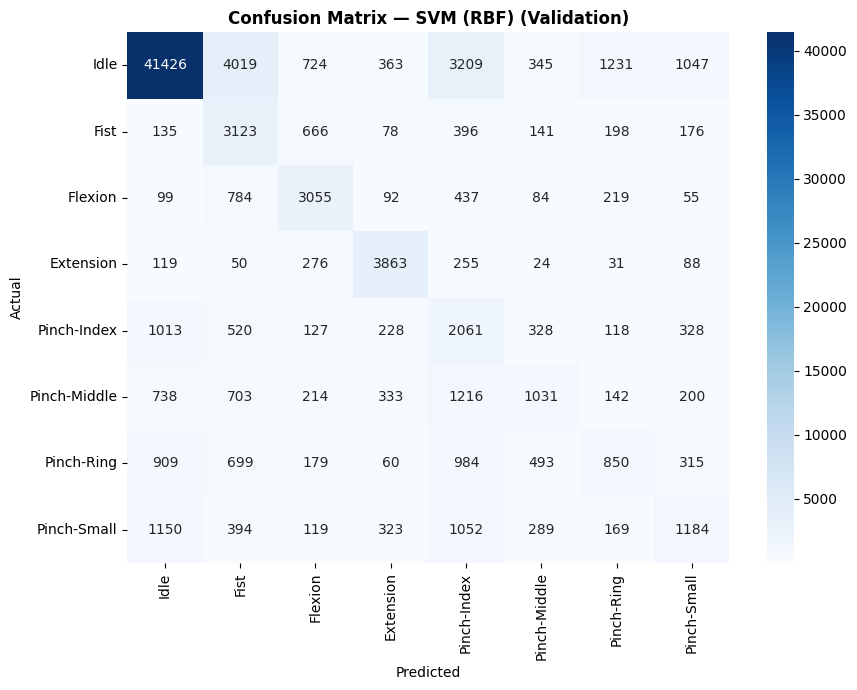

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

MAX_SVM = 50_000
if len(X_train) > MAX_SVM:
    # Stratified sample from original X_train so all 8 classes are represented
    X_svm, _, y_svm, _ = train_test_split(
        X_train, y_train_enc,
        train_size=MAX_SVM,
        stratify=y_train_enc,
        random_state=RANDOM_STATE,
    )
    print(f"SVM training on {MAX_SVM:,} stratified windows from original train set")
else:
    X_svm, y_svm = X_train, y_train_enc

print("Training SVM ...")
t0  = time.time()
svm = SVC(kernel="rbf", class_weight="balanced", probability=True,
          random_state=RANDOM_STATE, cache_size=2000)
svm.fit(X_svm, y_svm)
t1  = time.time()

y_pred = svm.predict(X_val)
evaluate("SVM (RBF)", svm, y_val_enc, y_pred, t1 - t0)


## Model 3 — k-Nearest Neighbours

Training k-NN (k=5) ...
  [Validation]
  Accuracy          : 0.6742
  Balanced Accuracy : 0.4565
  Macro-F1          : 0.4436  ← primary metric
  Macro Precision   : 0.4697
  Macro Recall      : 0.4565
  Weighted-F1       : 0.6715
  ROC-AUC (macro)   : 0.7728
  PR-AUC  (macro)   : 0.3805
  Train time        : 0.3s

              precision    recall  f1-score   support

        Idle       0.86      0.84      0.85     52364
        Fist       0.26      0.65      0.37      4913
     Flexion       0.56      0.52      0.54      4825
   Extension       0.71      0.77      0.74      4706
 Pinch-Index       0.34      0.24      0.28      4723
Pinch-Middle       0.31      0.27      0.29      4577
  Pinch-Ring       0.29      0.15      0.20      4489
 Pinch-Small       0.43      0.21      0.28      4680

    accuracy                           0.67     85277
   macro avg       0.47      0.46      0.44     85277
weighted avg       0.69      0.67      0.67     85277



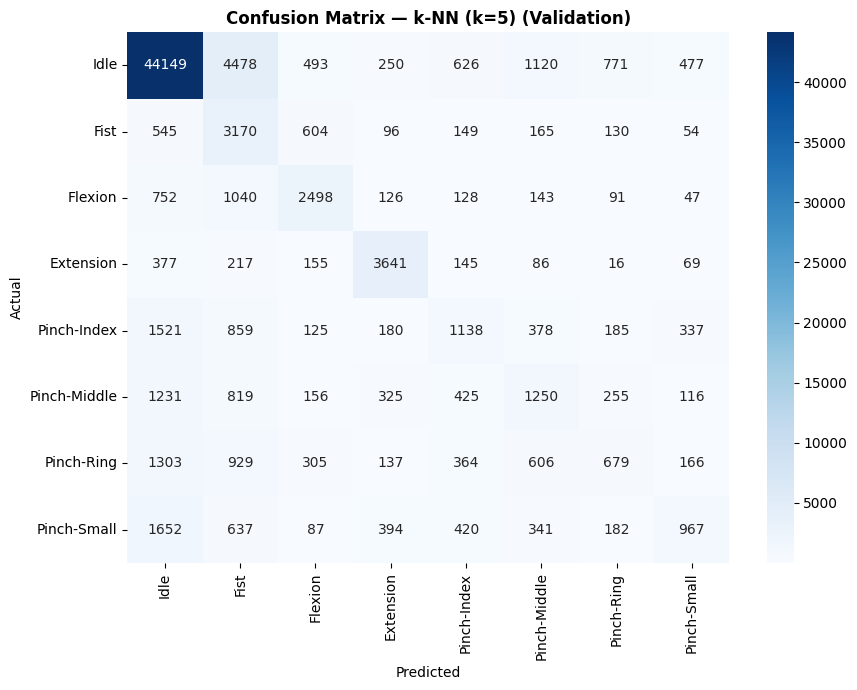

In [9]:
print("Training k-NN (k=5) ...")
t0  = time.time()
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train_enc)  # kNN has no class_weight param — use original dist
t1  = time.time()

y_pred = knn.predict(X_val)
evaluate("k-NN (k=5)", knn, y_val_enc, y_pred, t1 - t0)


## Model 4 — Decision Tree

Training Decision Tree ...
  [Validation]
  Accuracy          : 0.5338
  Balanced Accuracy : 0.4723
  Macro-F1          : 0.4038  ← primary metric
  Macro Precision   : 0.3772
  Macro Recall      : 0.4723
  Weighted-F1       : 0.5720
  ROC-AUC (macro)   : 0.6858
  PR-AUC  (macro)   : 0.2857
  Train time        : 172.1s

              precision    recall  f1-score   support

        Idle       0.89      0.58      0.70     52364
        Fist       0.30      0.59      0.40      4913
     Flexion       0.46      0.67      0.54      4825
   Extension       0.64      0.82      0.72      4706
 Pinch-Index       0.16      0.27      0.20      4723
Pinch-Middle       0.21      0.36      0.26      4577
  Pinch-Ring       0.17      0.16      0.17      4489
 Pinch-Small       0.18      0.34      0.23      4680

    accuracy                           0.53     85277
   macro avg       0.38      0.47      0.40     85277
weighted avg       0.67      0.53      0.57     85277



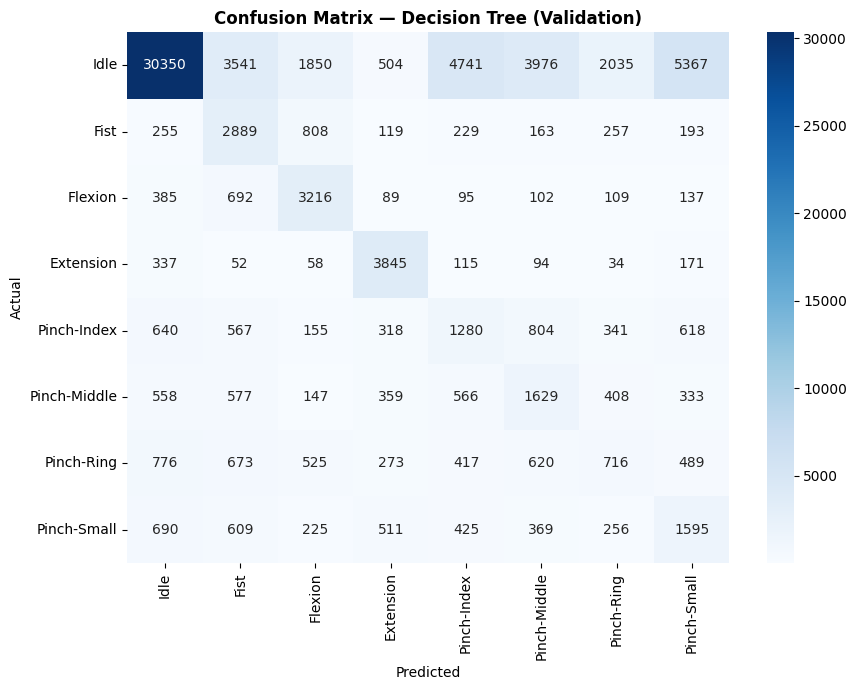

In [10]:
print("Training Decision Tree ...")
t0  = time.time()
dt  = DecisionTreeClassifier(
        max_depth=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
      )
dt.fit(X_train, y_train_enc)
t1  = time.time()

y_pred = dt.predict(X_val)
evaluate("Decision Tree", dt, y_val_enc, y_pred, t1 - t0)


## Model 5 — Random Forest

Training Random Forest ...
  [Validation]
  Accuracy          : 0.7287
  Balanced Accuracy : 0.5312
  Macro-F1          : 0.5244  ← primary metric
  Macro Precision   : 0.6214
  Macro Recall      : 0.5312
  Weighted-F1       : 0.7125
  ROC-AUC (macro)   : 0.9061
  PR-AUC  (macro)   : 0.5929
  Train time        : 652.3s

              precision    recall  f1-score   support

        Idle       0.84      0.88      0.86     52364
        Fist       0.32      0.78      0.45      4913
     Flexion       0.78      0.73      0.76      4825
   Extension       0.74      0.90      0.81      4706
 Pinch-Index       0.64      0.21      0.31      4723
Pinch-Middle       0.50      0.31      0.38      4577
  Pinch-Ring       0.61      0.15      0.24      4489
 Pinch-Small       0.54      0.29      0.38      4680

    accuracy                           0.73     85277
   macro avg       0.62      0.53      0.52     85277
weighted avg       0.74      0.73      0.71     85277



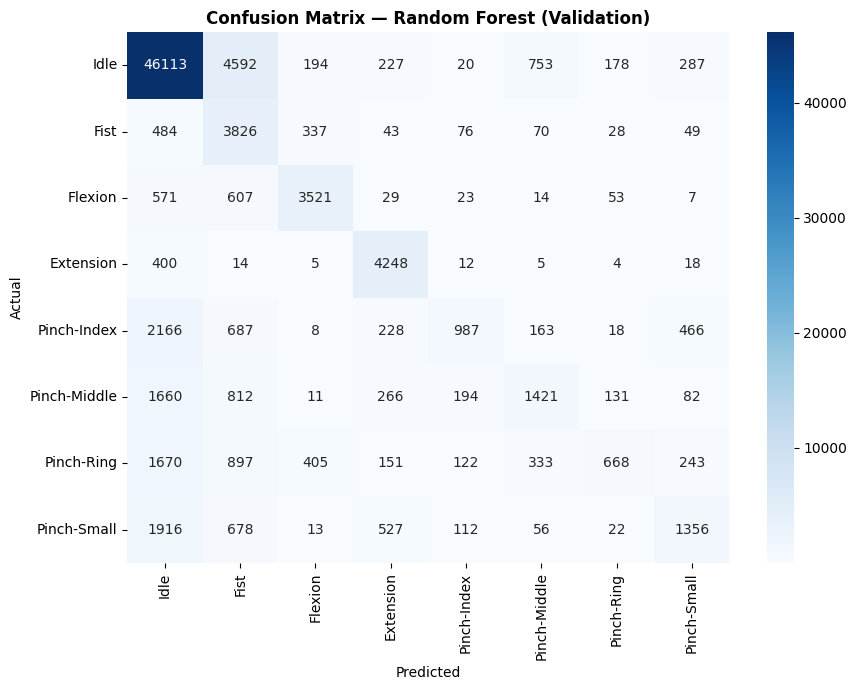

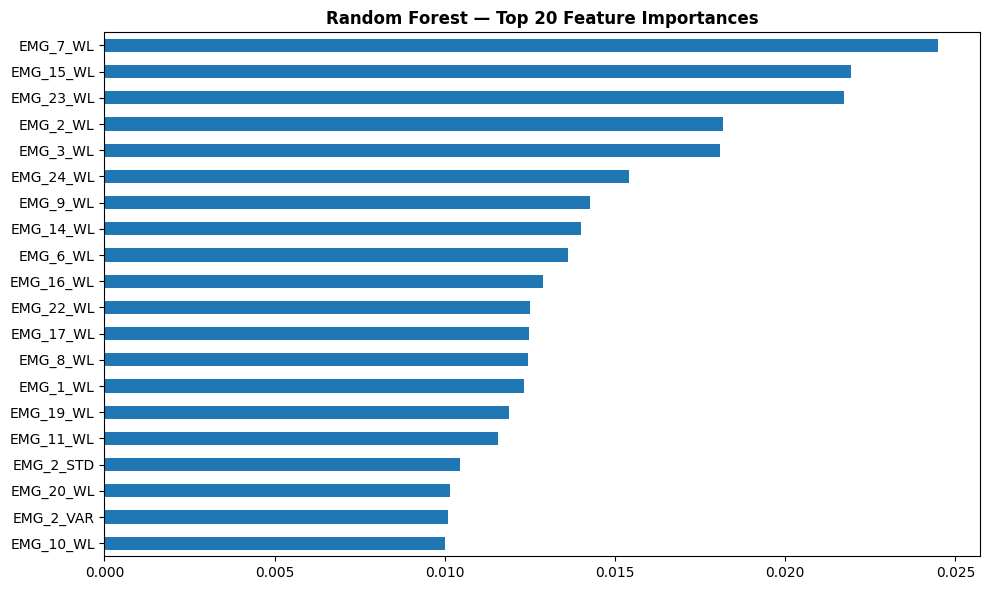

In [11]:
print("Training Random Forest ...")
t0  = time.time()
rf  = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
      )
rf.fit(X_train, y_train_enc)
t1  = time.time()

y_pred = rf.predict(X_val)
evaluate("Random Forest", rf, y_val_enc, y_pred, t1 - t0)

# Feature importance (top 20)
importances = pd.Series(rf.feature_importances_,
                         index=[feat_cols[i] for i in vt.get_support(indices=True)])
top20 = importances.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top20.plot(kind="barh", ax=ax)
ax.set_title("Random Forest — Top 20 Feature Importances", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Model 6 — Gradient Boosting

Gradient Boosting training on 100,000 stratified windows
Training Gradient Boosting ...
  [Validation]
  Accuracy          : 0.6404
  Balanced Accuracy : 0.5826
  Macro-F1          : 0.4994  ← primary metric
  Macro Precision   : 0.4688
  Macro Recall      : 0.5826
  Weighted-F1       : 0.6667
  ROC-AUC (macro)   : 0.8813
  PR-AUC  (macro)   : 0.5657
  Train time        : 8525.4s

              precision    recall  f1-score   support

        Idle       0.96      0.68      0.80     52364
        Fist       0.33      0.78      0.46      4913
     Flexion       0.57      0.77      0.65      4825
   Extension       0.59      0.91      0.72      4706
 Pinch-Index       0.36      0.38      0.37      4723
Pinch-Middle       0.30      0.45      0.36      4577
  Pinch-Ring       0.38      0.26      0.31      4489
 Pinch-Small       0.27      0.44      0.33      4680

    accuracy                           0.64     85277
   macro avg       0.47      0.58      0.50     85277
weighted avg       0

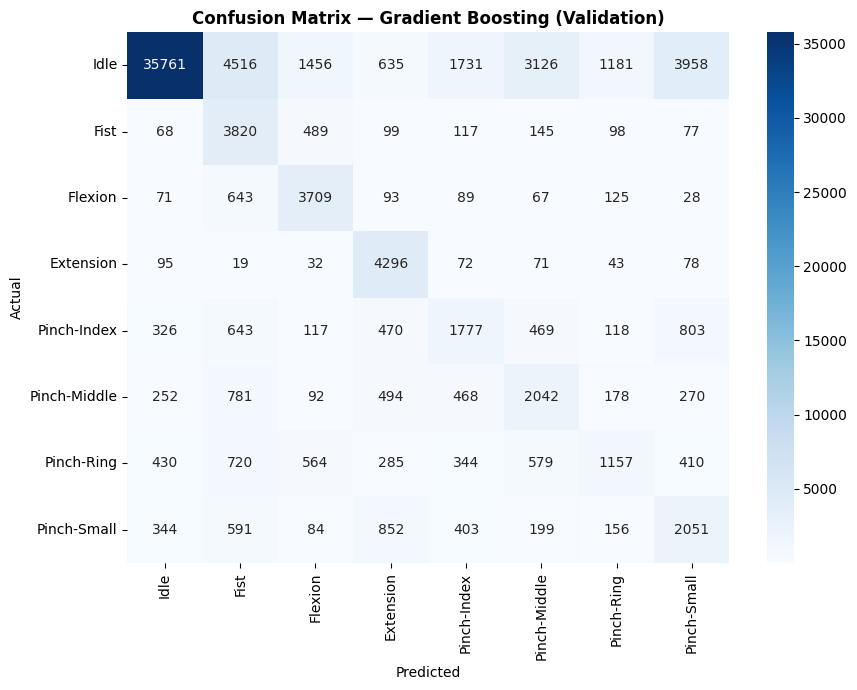

In [12]:
from sklearn.model_selection import train_test_split

MAX_GB = 100_000
if len(X_train) > MAX_GB:
    # Stratified sample so all classes are represented in the subset
    X_gb, _, y_gb, _ = train_test_split(
        X_train, y_train_enc,
        train_size=MAX_GB,
        stratify=y_train_enc,
        random_state=RANDOM_STATE,
    )
    # GB has no class_weight — use sample_weight for the subset
    sw_gb = compute_sample_weight("balanced", y=y_gb)
    print(f"Gradient Boosting training on {MAX_GB:,} stratified windows")
else:
    X_gb, y_gb, sw_gb = X_train, y_train_enc, sample_weights

print("Training Gradient Boosting ...")
t0 = time.time()
gb = GradientBoostingClassifier(
       n_estimators=100,
       max_depth=5,
       learning_rate=0.1,
       random_state=RANDOM_STATE,
     )
gb.fit(X_gb, y_gb, sample_weight=sw_gb)
t1 = time.time()

y_pred = gb.predict(X_val)
evaluate("Gradient Boosting", gb, y_val_enc, y_pred, t1 - t0)


## Model 7 — XGBoost

Training XGBoost ...
  [Validation]
  Accuracy          : 0.6414
  Balanced Accuracy : 0.5977
  Macro-F1          : 0.5088  ← primary metric
  Macro Precision   : 0.4735
  Macro Recall      : 0.5977
  Weighted-F1       : 0.6666
  ROC-AUC (macro)   : 0.8897
  PR-AUC  (macro)   : 0.5969
  Train time        : 196.4s

              precision    recall  f1-score   support

        Idle       0.96      0.67      0.79     52364
        Fist       0.32      0.79      0.46      4913
     Flexion       0.54      0.79      0.64      4825
   Extension       0.64      0.94      0.76      4706
 Pinch-Index       0.37      0.40      0.39      4723
Pinch-Middle       0.34      0.47      0.39      4577
  Pinch-Ring       0.33      0.25      0.29      4489
 Pinch-Small       0.29      0.46      0.35      4680

    accuracy                           0.64     85277
   macro avg       0.47      0.60      0.51     85277
weighted avg       0.74      0.64      0.67     85277



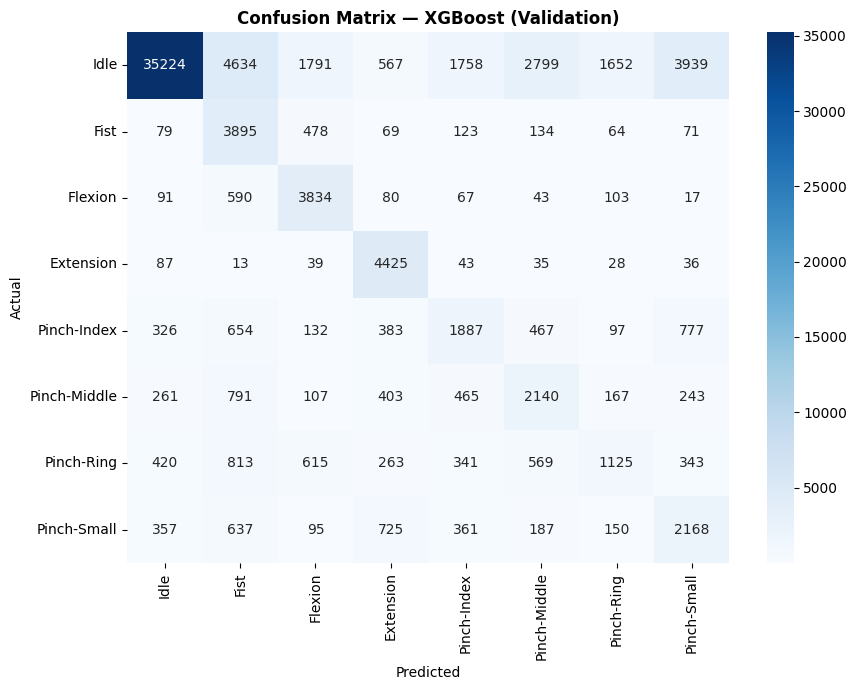

In [13]:
print("Training XGBoost ...")
t0    = time.time()
xgbc  = xgb.XGBClassifier(
          n_estimators=200,
          max_depth=6,
          learning_rate=0.1,
          eval_metric="mlogloss",
          random_state=RANDOM_STATE,
          n_jobs=-1,
          tree_method="hist",
        )
# XGBoost has no class_weight param — pass sample_weight
xgbc.fit(X_train, y_train_enc, sample_weight=sample_weights)
t1    = time.time()

y_pred = xgbc.predict(X_val)
evaluate("XGBoost", xgbc, y_val_enc, y_pred, t1 - t0)


## Model 8 — LightGBM

Training LightGBM ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [Validation]
  Accuracy          : 0.6393
  Balanced Accuracy : 0.6001
  Macro-F1          : 0.5100  ← primary metric
  Macro Precision   : 0.4732
  Macro Recall      : 0.6001
  Weighted-F1       : 0.6655
  ROC-AUC (macro)   : 0.8886
  PR-AUC  (macro)   : 0.5954
  Train time        : 163.4s

              precision    recall  f1-score   support

        Idle       0.96      0.67      0.79     52364
        Fist       0.33      0.79      0.46      4913
     Flexion       0.55      0.81      0.65      4825
   Extension       0.63      0.93      0.75      4706
 Pinch-Index       0.38      0.41      0.39      4723
Pinch-Middle       0.34      0.47      0.40      4577
  Pinch-Ring       0.33      0.27      0.29      4489
 Pinch-Small       0.28      0.46      0.35      4680

    accuracy                           0.64     85277
   macro avg       0.47      0.60      0.51     85277
weighted avg       0.74      0.64      0.67     85277



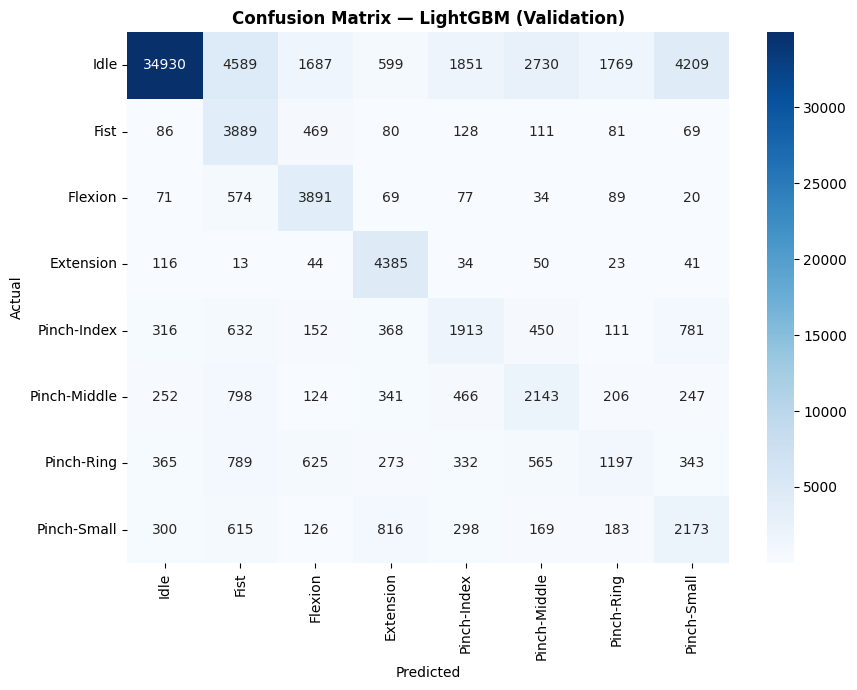

In [14]:
print("Training LightGBM ...")
t0    = time.time()
lgbc  = lgb.LGBMClassifier(
          n_estimators=200,
          max_depth=6,
          learning_rate=0.1,
          class_weight="balanced",
          random_state=RANDOM_STATE,
          n_jobs=-1,
          verbose=-1,
        )
lgbc.fit(X_train, y_train_enc)
t1    = time.time()

y_pred = lgbc.predict(X_val)
evaluate("LightGBM", lgbc, y_val_enc, y_pred, t1 - t0)


## Model 9 — MLP (Multi-Layer Perceptron)

Using device: cuda
  Epoch 05/50  loss=0.9167  val_macro_f1=0.5224
  Epoch 10/50  loss=0.8173  val_macro_f1=0.5023
  Epoch 15/50  loss=0.7381  val_macro_f1=0.5247
  Epoch 20/50  loss=0.7050  val_macro_f1=0.5236
  Epoch 25/50  loss=0.6618  val_macro_f1=0.5262
  Epoch 30/50  loss=0.6427  val_macro_f1=0.5199
  Epoch 35/50  loss=0.6200  val_macro_f1=0.5243
  Epoch 40/50  loss=0.6128  val_macro_f1=0.5204
  Epoch 45/50  loss=0.5982  val_macro_f1=0.5220
  Epoch 50/50  loss=0.5936  val_macro_f1=0.5196
  [Validation]
  Accuracy          : 0.6184
  Balanced Accuracy : 0.6415
  Macro-F1          : 0.5346  ← primary metric
  Macro Precision   : 0.4909
  Macro Recall      : 0.6415
  Weighted-F1       : 0.6497
  ROC-AUC (macro)   : 0.8962
  PR-AUC  (macro)   : 0.6500
  Train time        : 305.4s

              precision    recall  f1-score   support

        Idle       0.97      0.60      0.74     52364
        Fist       0.37      0.74      0.49      4913
     Flexion       0.57      0.80      0.67

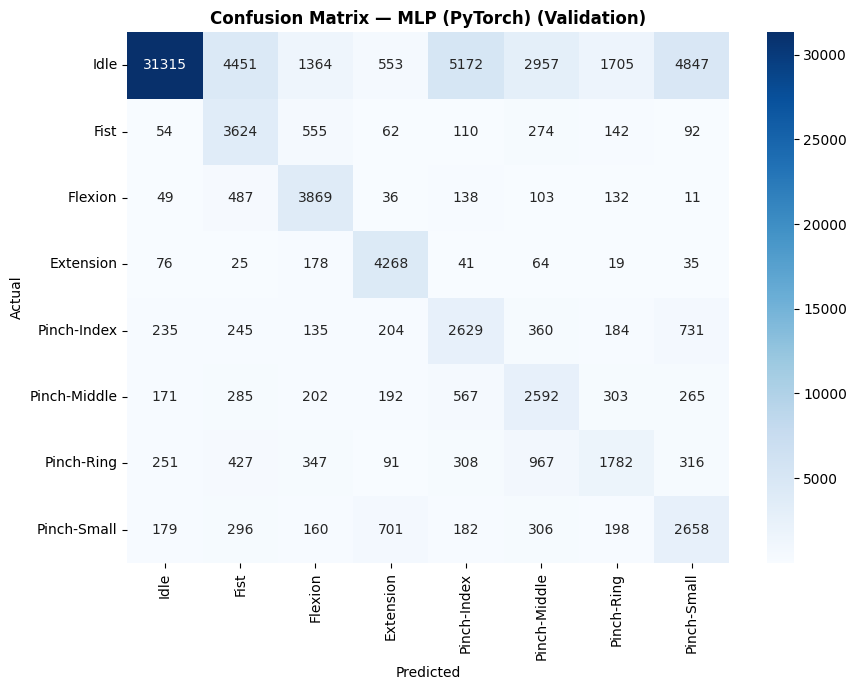

In [15]:
# PyTorch MLP — 3 hidden layers
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

def make_loader(X, y, batch=1024, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

# Train on original X_train — weighted loss handles imbalance (no SMOTE)
train_loader_mlp = make_loader(X_train, y_train_enc)
val_loader_mlp   = make_loader(X_val,   y_val_enc,  shuffle=False)
test_loader_mlp  = make_loader(X_test,  y_test_enc, shuffle=False)

# Weighted loss — single imbalance correction (not combined with SMOTE)
cw_tensor = torch.tensor(list(class_weight_dict.values()),
                          dtype=torch.float32).to(device)
loss_fn   = nn.CrossEntropyLoss(weight=cw_tensor)

mlp   = MLP(X_train.shape[1], n_classes).to(device)
opt   = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)

EPOCHS  = 50
PATIENCE = 15
best_val_f1 = -np.inf
best_state  = None
patience_ctr = 0

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    mlp.train()
    total_loss = 0
    for xb, yb in train_loader_mlp:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(mlp(xb), yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    sched.step()

    # Validation Macro-F1 for early stopping
    mlp.eval()
    val_preds = []
    with torch.no_grad():
        for xb, _ in val_loader_mlp:
            val_preds.append(mlp(xb.to(device)).argmax(dim=1).cpu().numpy())
    val_f1 = f1_score(y_val_enc, np.concatenate(val_preds),
                      average="macro", zero_division=0)

    if epoch % 5 == 0:
        print(f"  Epoch {epoch:02d}/{EPOCHS}  "
              f"loss={total_loss/len(train_loader_mlp):.4f}  "
              f"val_macro_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch} (best val Macro-F1={best_val_f1:.4f})")
            break

mlp.load_state_dict(best_state)
t1 = time.time()

# Evaluate on validation set (consistent with all other baselines)
mlp.eval()
preds, probas = [], []
with torch.no_grad():
    for xb, _ in val_loader_mlp:
        logits = mlp(xb.to(device))
        preds.append(logits.argmax(dim=1).cpu().numpy())
        probas.append(torch.softmax(logits, dim=1).cpu().numpy())
y_pred      = np.concatenate(preds)
mlp_proba   = np.concatenate(probas)
evaluate("MLP (PyTorch)", mlp_proba, y_val_enc, y_pred, t1 - t0)


## Model 10 — 1D-CNN

The 168 features are reshaped to **(7 metrics × 24 channels)** — treating
each metric as a "timestep" and each channel as a feature at that timestep.
Convolutions then learn patterns across the 7 feature types (IEMG removed).

Features available : 168
  Epoch 05/50  loss=1.2137  val_macro_f1=0.4400
  Epoch 10/50  loss=1.0873  val_macro_f1=0.4743
  Epoch 15/50  loss=1.0148  val_macro_f1=0.4815
  Epoch 20/50  loss=0.9667  val_macro_f1=0.4822
  Early stopping at epoch 24 (best val Macro-F1=0.5002)
  [Validation]
  Accuracy          : 0.6205
  Balanced Accuracy : 0.5850
  Macro-F1          : 0.5002  ← primary metric
  Macro Precision   : 0.4664
  Macro Recall      : 0.5850
  Weighted-F1       : 0.6523
  ROC-AUC (macro)   : 0.8738
  PR-AUC  (macro)   : 0.5867
  Train time        : 179.7s

              precision    recall  f1-score   support

        Idle       0.96      0.65      0.77     52364
        Fist       0.34      0.76      0.47      4913
     Flexion       0.49      0.69      0.58      4825
   Extension       0.74      0.91      0.82      4706
 Pinch-Index       0.27      0.37      0.32      4723
Pinch-Middle       0.27      0.60      0.37      4577
  Pinch-Ring       0.31      0.32      0.32      4489

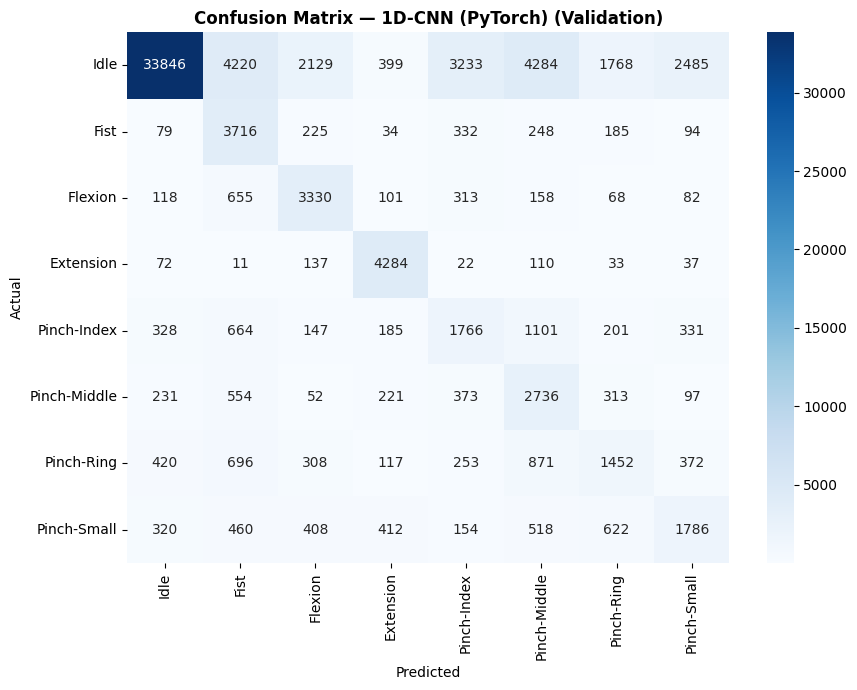

In [16]:
class CNN1D(nn.Module):
    def __init__(self, n_channels, n_metrics, n_classes):
        super().__init__()
        # Input shape: (batch, n_metrics=7, n_channels=24)
        self.conv = nn.Sequential(
            nn.Conv1d(n_metrics, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),        nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # → (batch, 128, 1)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.fc(self.conv(x))

# N_METRICS = 7 after removing IEMG (was 8)
N_METRICS  = len(["MAV","RMS","STD","VAR","WL","ZC","SSC"])  # 7
N_CHANNELS = 24   # EMG electrodes

def reshape_for_cnn(X):
    # X shape: (n_windows, 168)
    # Reshape to (n_windows, 7, 24) → (batch, n_metrics, n_channels)
    # feat_col order: metric-major (all 24 channels per metric, then next metric)
    return X.reshape(-1, N_METRICS, N_CHANNELS)

def make_cnn_loader(X, y, batch=1024, shuffle=True):
    Xr = torch.tensor(reshape_for_cnn(X), dtype=torch.float32)
    ds = TensorDataset(Xr, torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

print(f"Features available : {X_train.shape[1]}")
assert X_train.shape[1] == N_METRICS * N_CHANNELS, (
    f"Expected {N_METRICS * N_CHANNELS} features for CNN reshape, "
    f"got {X_train.shape[1]}"
)

# Train on original X_train — weighted loss handles imbalance (no SMOTE)
cnn_train_loader = make_cnn_loader(X_train, y_train_enc)
cnn_val_loader   = make_cnn_loader(X_val,   y_val_enc,  shuffle=False)
cnn_test_loader  = make_cnn_loader(X_test,  y_test_enc, shuffle=False)

cnn     = CNN1D(N_CHANNELS, N_METRICS, n_classes).to(device)
opt_cnn = torch.optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
sched_cnn = torch.optim.lr_scheduler.StepLR(opt_cnn, step_size=10, gamma=0.5)
# loss_fn reused from MLP cell (same weighted CrossEntropyLoss)

EPOCHS   = 50
PATIENCE = 15
best_val_f1_cnn = -np.inf
best_state_cnn  = None
patience_ctr_cnn = 0

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    cnn.train()
    total_loss = 0
    for xb, yb in cnn_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_cnn.zero_grad()
        loss = loss_fn(cnn(xb), yb)
        loss.backward()
        opt_cnn.step()
        total_loss += loss.item()
    sched_cnn.step()

    # Validation Macro-F1 for early stopping
    cnn.eval()
    val_preds = []
    with torch.no_grad():
        for xb, _ in cnn_val_loader:
            val_preds.append(cnn(xb.to(device)).argmax(dim=1).cpu().numpy())
    val_f1 = f1_score(y_val_enc, np.concatenate(val_preds),
                      average="macro", zero_division=0)

    if epoch % 5 == 0:
        print(f"  Epoch {epoch:02d}/{EPOCHS}  "
              f"loss={total_loss/len(cnn_train_loader):.4f}  "
              f"val_macro_f1={val_f1:.4f}")

    if val_f1 > best_val_f1_cnn:
        best_val_f1_cnn  = val_f1
        best_state_cnn   = {k: v.cpu().clone() for k, v in cnn.state_dict().items()}
        patience_ctr_cnn = 0
    else:
        patience_ctr_cnn += 1
        if patience_ctr_cnn >= PATIENCE:
            print(f"  Early stopping at epoch {epoch} (best val Macro-F1={best_val_f1_cnn:.4f})")
            break

cnn.load_state_dict(best_state_cnn)
t1 = time.time()

# Evaluate on validation (consistent with all other baselines)
cnn.eval()
preds, probas = [], []
with torch.no_grad():
    for xb, _ in cnn_val_loader:
        logits = cnn(xb.to(device))
        preds.append(logits.argmax(dim=1).cpu().numpy())
        probas.append(torch.softmax(logits, dim=1).cpu().numpy())
y_pred    = np.concatenate(preds)
cnn_proba = np.concatenate(probas)
evaluate("1D-CNN (PyTorch)", cnn_proba, y_val_enc, y_pred, t1 - t0)


## Comparison Table — All Baselines

Best validation baseline: MLP (PyTorch)
Macro-F1: 0.5346

Plotting ROC and PR curves for best baseline: MLP (PyTorch)


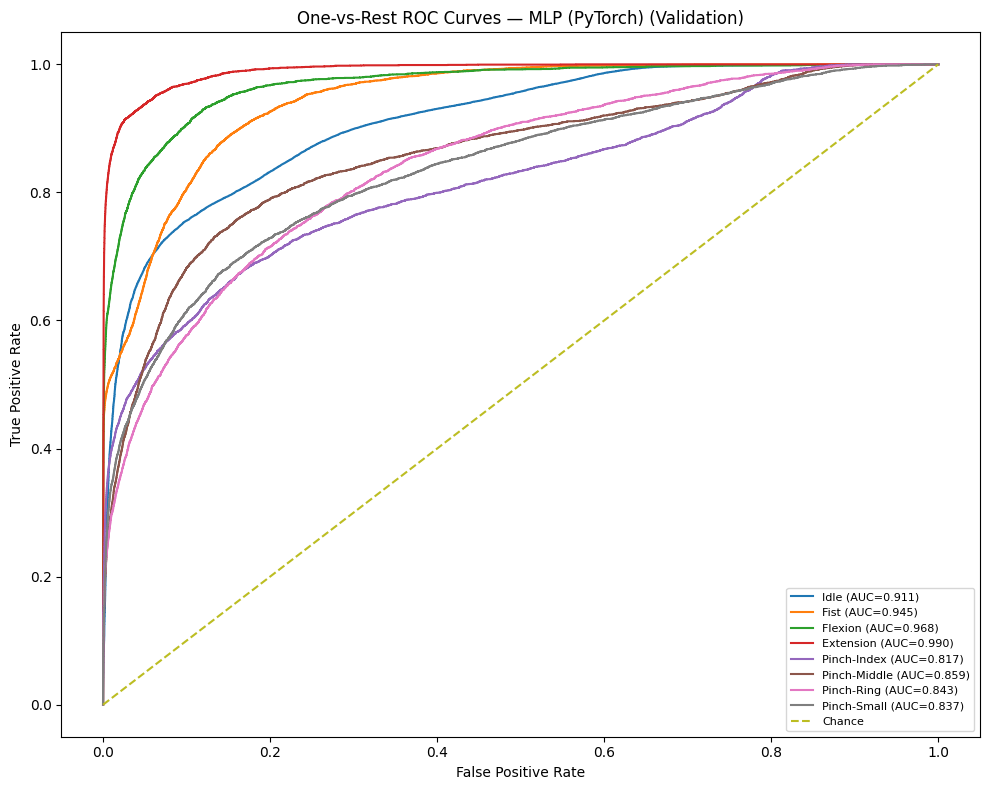

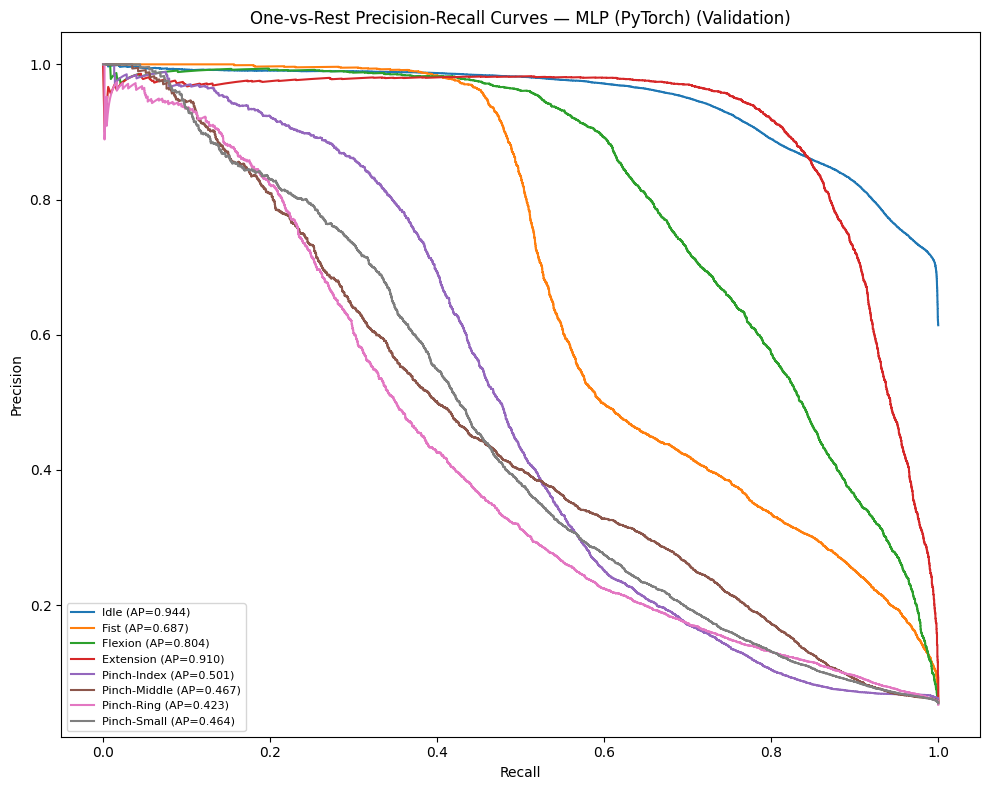

In [17]:
#  Actual ROC and Precision-Recall curves for best baseline 
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# Determine best model from VALIDATION Macro-F1
results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("Macro-F1", ascending=False)
    .reset_index(drop=True)
)

best_model_name = results_df.loc[0, "Model"]

print(f"Best validation baseline: {best_model_name}")
print(f"Macro-F1: {results_df.loc[0, 'Macro-F1']:.4f}")

print(f"\nPlotting ROC and PR curves for best baseline: {best_model_name}")

# Obtain validation probability scores from the already-trained best model
if best_model_name == "MLP (PyTorch)":
    best_proba = mlp_proba

elif best_model_name == "1D-CNN (PyTorch)":
    best_proba = cnn_proba

else:
    sklearn_models = {
        "Logistic Regression": lr,
        "SVM (RBF)": svm,
        "k-NN (k=5)": knn,
        "Decision Tree": dt,
        "Random Forest": rf,
        "Gradient Boosting": gb,
        "XGBoost": xgbc,
        "LightGBM": lgbc,
    }

    best_model = sklearn_models[best_model_name]
    best_proba = best_model.predict_proba(X_val)

# One-vs-Rest binary representation
y_val_bin = label_binarize(
    y_val_enc,
    classes=np.arange(n_classes)
)


# ROC CURVES — One-vs-Rest

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_val_bin[:, i],
        best_proba[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC={class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"One-vs-Rest ROC Curves — {best_model_name} (Validation)"
)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# PRECISION-RECALL CURVES — One-vs-Rest
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):

    precision, recall, _ = precision_recall_curve(
        y_val_bin[:, i],
        best_proba[:, i]
    )

    class_ap = average_precision_score(
        y_val_bin[:, i],
        best_proba[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP={class_ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"One-vs-Rest Precision-Recall Curves — "
    f"{best_model_name} (Validation)"
)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## Save Split Information for Proposed Model Notebook

In [18]:
# Save subject split so the GNN notebook uses the exact same train/test subjects
split_info = {
    "train_subjects": [int(s) for s in train_subjects],
    "val_subjects"  : [int(s) for s in val_subjects],
    "test_subjects" : [int(s) for s in test_subjects],
    "feat_cols"     : feat_cols,
    "n_classes"     : int(n_classes),
    "label_classes" : [int(c) for c in le.classes_],
}
import json
with open(OUTPUT_FOLDER / "split_info.json", "w") as f:
    json.dump(split_info, f, indent=2)
print("Saved → task2_results/split_info.json")
results_df.to_csv(OUTPUT_FOLDER / "baseline_results.csv", index=False)

Saved → task2_results/split_info.json
